<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Stacked Charts**


Estimated time needed: **45** minutes


In this lab, you will focus on visualizing data specifically using stacked charts. You will use SQL queries to extract the necessary data and apply stacked charts to analyze the composition and comparison within the data.


## Objectives


In this lab, you will perform the following:


- Visualize the composition of data using stacked charts.

- Compare multiple variables across different categories using stacked charts.

- Analyze trends within stacked chart visualizations.


## Setup: Downloading and Loading the Data
**Install the libraries**


In [1]:
!pip install pandas

In [2]:
!pip install matplotlib


**Download and Load the Data**


To start, download and load the dataset into a `pandas` DataFrame.



### Step 1: Download the dataset


In [3]:
!wget -O survey-data.csv https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv

'wget' is not recognized as an internal or external command,
operable program or batch file.


### Step 2: Import necessary libraries and load the dataset


In [4]:
import pandas as pd
import matplotlib.pyplot as plt

### Load the data


In [69]:
df = pd.read_csv("survey_data.csv")

### Display the first few rows of the data to understand its structure


In [71]:
df.head()


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Task 1: Stacked Chart for Composition of Job Satisfaction Across Age Groups


##### 1. Stacked Chart of Median `JobSatPoints_6` and `JobSatPoints_7` for Different Age Groups


Visualize the composition of job satisfaction scores (`JobSatPoints_6` and `JobSatPoints_7`) across various age groups. This will help in understanding the breakdown of satisfaction levels across different demographics.



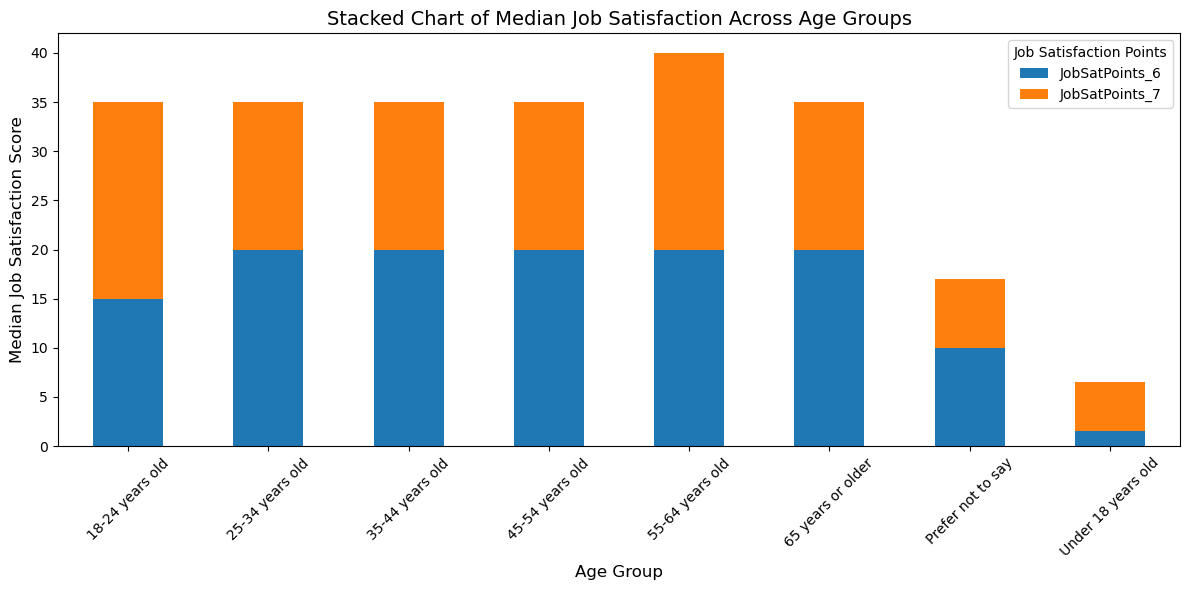

In [13]:
##Write your code here


# Step 1: Group by Age and calculate median of satisfaction points
median_scores = df.groupby('Age')[['JobSatPoints_6', 'JobSatPoints_7']].median()

# Step 2: Plot stacked bar chart
median_scores.plot(kind='bar', stacked=True, figsize=(12, 6), color=['#1f77b4', '#ff7f0e'])

plt.title('Stacked Chart of Median Job Satisfaction Across Age Groups', fontsize=14)
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Median Job Satisfaction Score', fontsize=12)
plt.legend(title='Job Satisfaction Points')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


##### Stacked Chart of `JobSatPoints_6` and `JobSatPoints_7` for Employment Status


Create a stacked chart to compare job satisfaction (`JobSatPoints_6` and `JobSatPoints_7`) across different employment statuses. This will show how satisfaction varies by employment type.


C:\Users\praka\AppData\Local\Temp\ipykernel_14228\2733200552.py:16: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


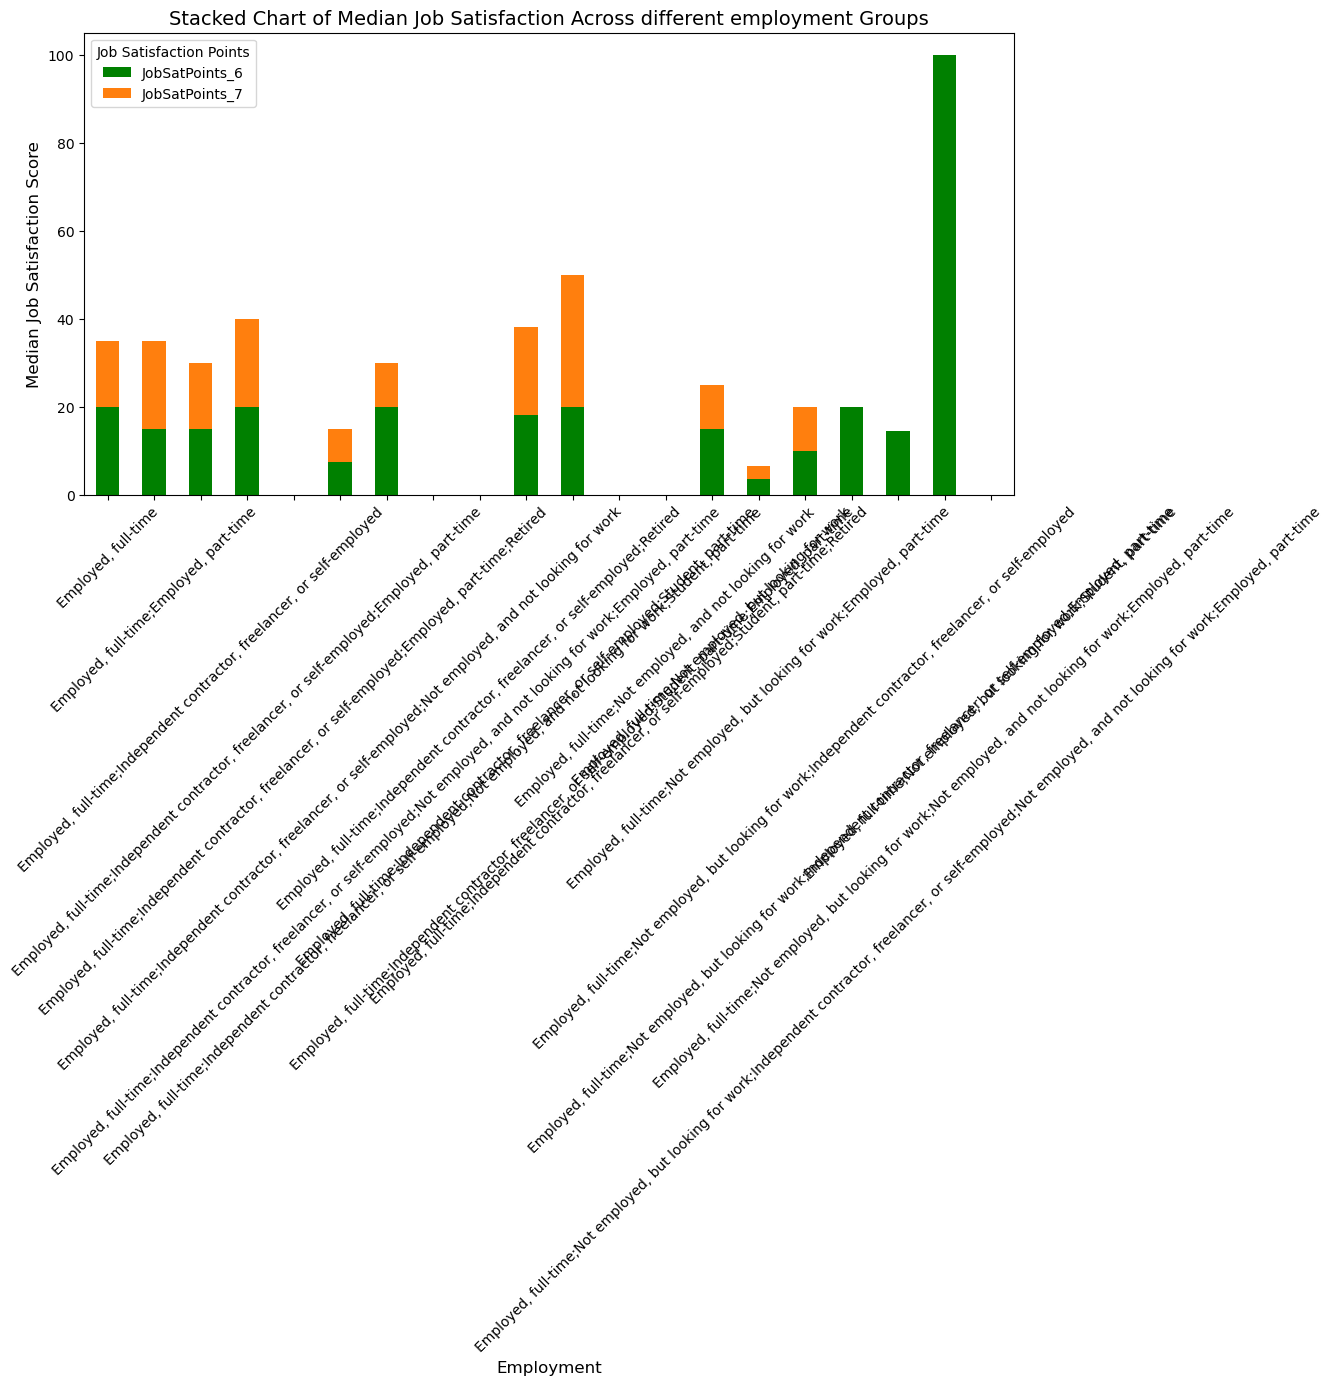

In [29]:
##Write your code here

#top 20 
# Step 1: Group by Age and calculate median of satisfaction points
median_scores = df.groupby('Employment')[['JobSatPoints_6', 'JobSatPoints_7']].median().head(20)

# Step 2: Plot stacked bar chart
median_scores.plot(kind='bar', stacked=True, figsize=(12, 6), color=['Green', '#ff7f0e'])


plt.title('Stacked Chart of Median Job Satisfaction Across different employment Groups', fontsize=14)
plt.xlabel('Employment', fontsize=12)
plt.ylabel('Median Job Satisfaction Score', fontsize=12)
plt.legend(title='Job Satisfaction Points')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Task 2: Stacked Chart for Compensation and Job Satisfaction by Age Group


##### This stacked chart visualizes the composition of compensation (`ConvertedCompYearly`) and job satisfaction (`JobSatPoints_6`) specifically for respondents aged 30-35.


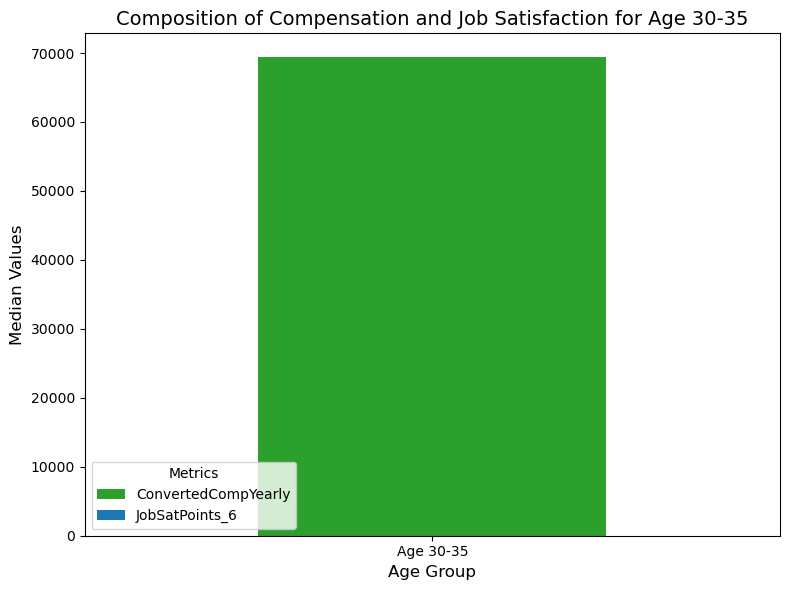

In [74]:


# Filter for the age group 30-35
# Since your age groups are like "35-44 years old", we need to pick the appropriate group
# For 30-35, it probably falls under "25-34 years old" if available
target_age_groups = ['25-34 years old', '35-44 years old']  # adjust based on your data

# Filter the DataFrame
df_filtered = df[df['Age'].isin(target_age_groups)]

# Drop rows with missing compensation or satisfaction
df_filtered = df_filtered.dropna(subset=['ConvertedCompYearly', 'JobSatPoints_6'])

# Compute median values
median_values = df_filtered[['ConvertedCompYearly', 'JobSatPoints_6']].median()

# Create a DataFrame for plotting
stacked_data = pd.DataFrame(median_values).T
stacked_data.index = ['Age 30-35']

# Plot stacked bar chart
stacked_data.plot(kind='bar', stacked=True, figsize=(8,6), color=['#2ca02c', '#1f77b4'])

plt.title('Composition of Compensation and Job Satisfaction for Age 30-35', fontsize=14)
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Median Values', fontsize=12)
plt.legend(title='Metrics')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()



##### Stacked Chart of Median Compensation and Job Satisfaction Across Age Group


Compare the median compensation and job satisfaction metrics across different age groups. This helps visualize how compensation and satisfaction levels differ by age.


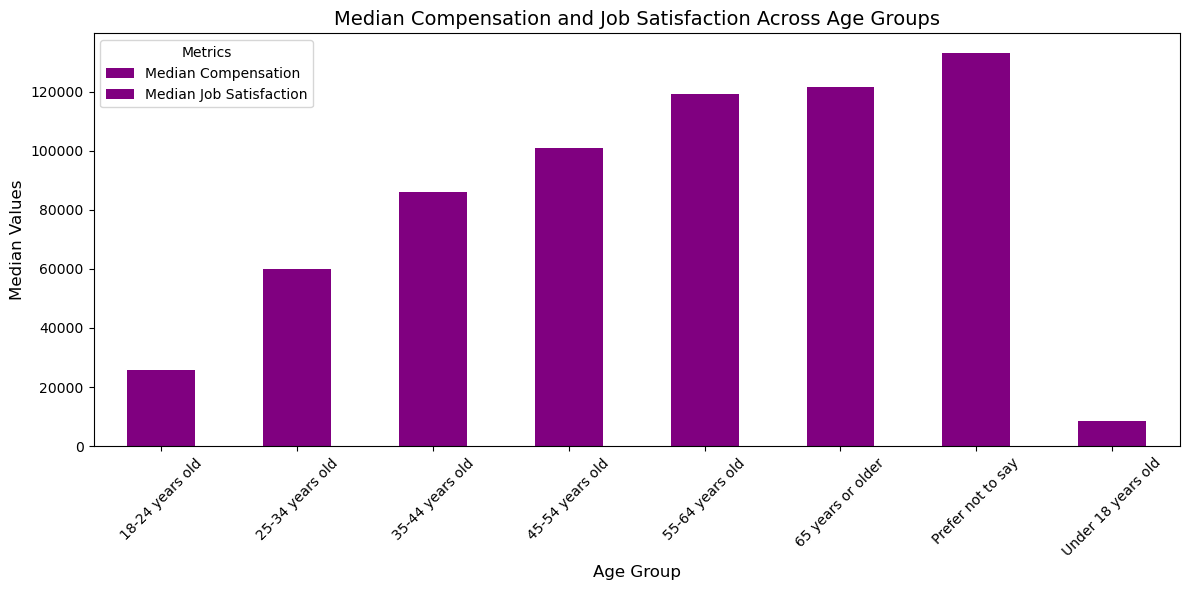

In [84]:

# Select relevant columns and drop missing values
df_age = df[['Age', 'ConvertedCompYearly', 'JobSatPoints_6']].dropna()

# Group by Age category and calculate median
median_by_age = df_age.groupby('Age')[['ConvertedCompYearly', 'JobSatPoints_6']].median()

# Rename columns for clarity
median_by_age.rename(columns={
    'ConvertedCompYearly': 'Median Compensation',
    'JobSatPoints_6': 'Median Job Satisfaction'
}, inplace=True)

# Plot stacked bar chart
median_by_age.plot(kind='bar', stacked=True, figsize=(12,6), color=['Purple'])

plt.title('Median Compensation and Job Satisfaction Across Age Groups', fontsize=14)
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Median Values', fontsize=12)
plt.legend(title='Metrics')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Task 3: Comparing Data Using Stacked Charts


##### 1. Stacked Chart of Preferred Databases by Age Group




Visualize the top databases that respondents from different age groups wish to learn. Create a stacked chart to show the proportion of each database in each age group.


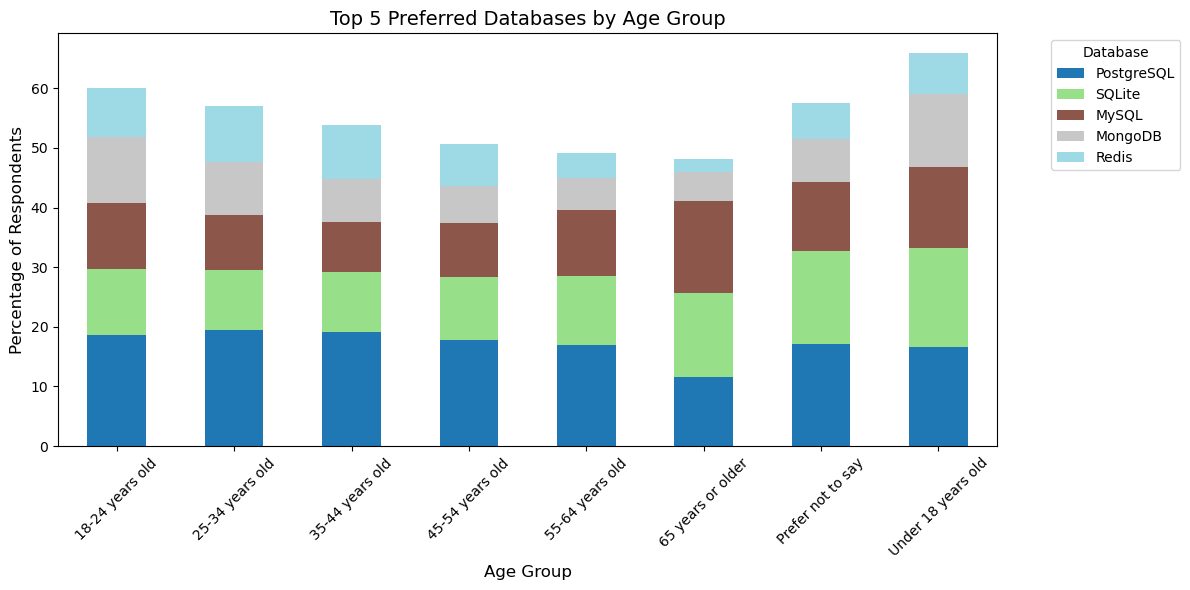

In [86]:
# Select relevant columns and drop missing values
df_db = df[['Age', 'DatabaseWantToWorkWith']].dropna()

# Split multiple databases if separated by semicolons and explode into separate rows
df_db = df_db.assign(DatabaseWantToWorkWith=df_db['DatabaseWantToWorkWith'].str.split(';')).explode('DatabaseWantToWorkWith')

# Strip whitespace
df_db['DatabaseWantToWorkWith'] = df_db['DatabaseWantToWorkWith'].str.strip()

# Pivot table: count of respondents per database per age group
pivot_table = df_db.pivot_table(index='Age', columns='DatabaseWantToWorkWith', aggfunc='size', fill_value=0)

# Convert counts to percentages (proportion in each age group)
pivot_table_percent = pivot_table.div(pivot_table.sum(axis=1), axis=0) * 100

# Optional: select top 5 databases overall for clarity
top_dbs = pivot_table.sum().sort_values(ascending=False).head(5).index
pivot_table_percent = pivot_table_percent[top_dbs]

# Plot stacked bar chart
pivot_table_percent.plot(kind='bar', stacked=True, figsize=(12,6), colormap='tab20')

plt.title('Top 5 Preferred Databases by Age Group', fontsize=14)
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Percentage of Respondents', fontsize=12)
plt.legend(title='Database', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##### 2. Stacked Chart of Employment Type by Job Satisfaction


Analyze the distribution of employment types within each job satisfaction level using a stacked chart. This will provide insights into how employment types are distributed across various satisfaction ratings.


C:\Users\praka\AppData\Local\Temp\ipykernel_14228\1170060858.py:20: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


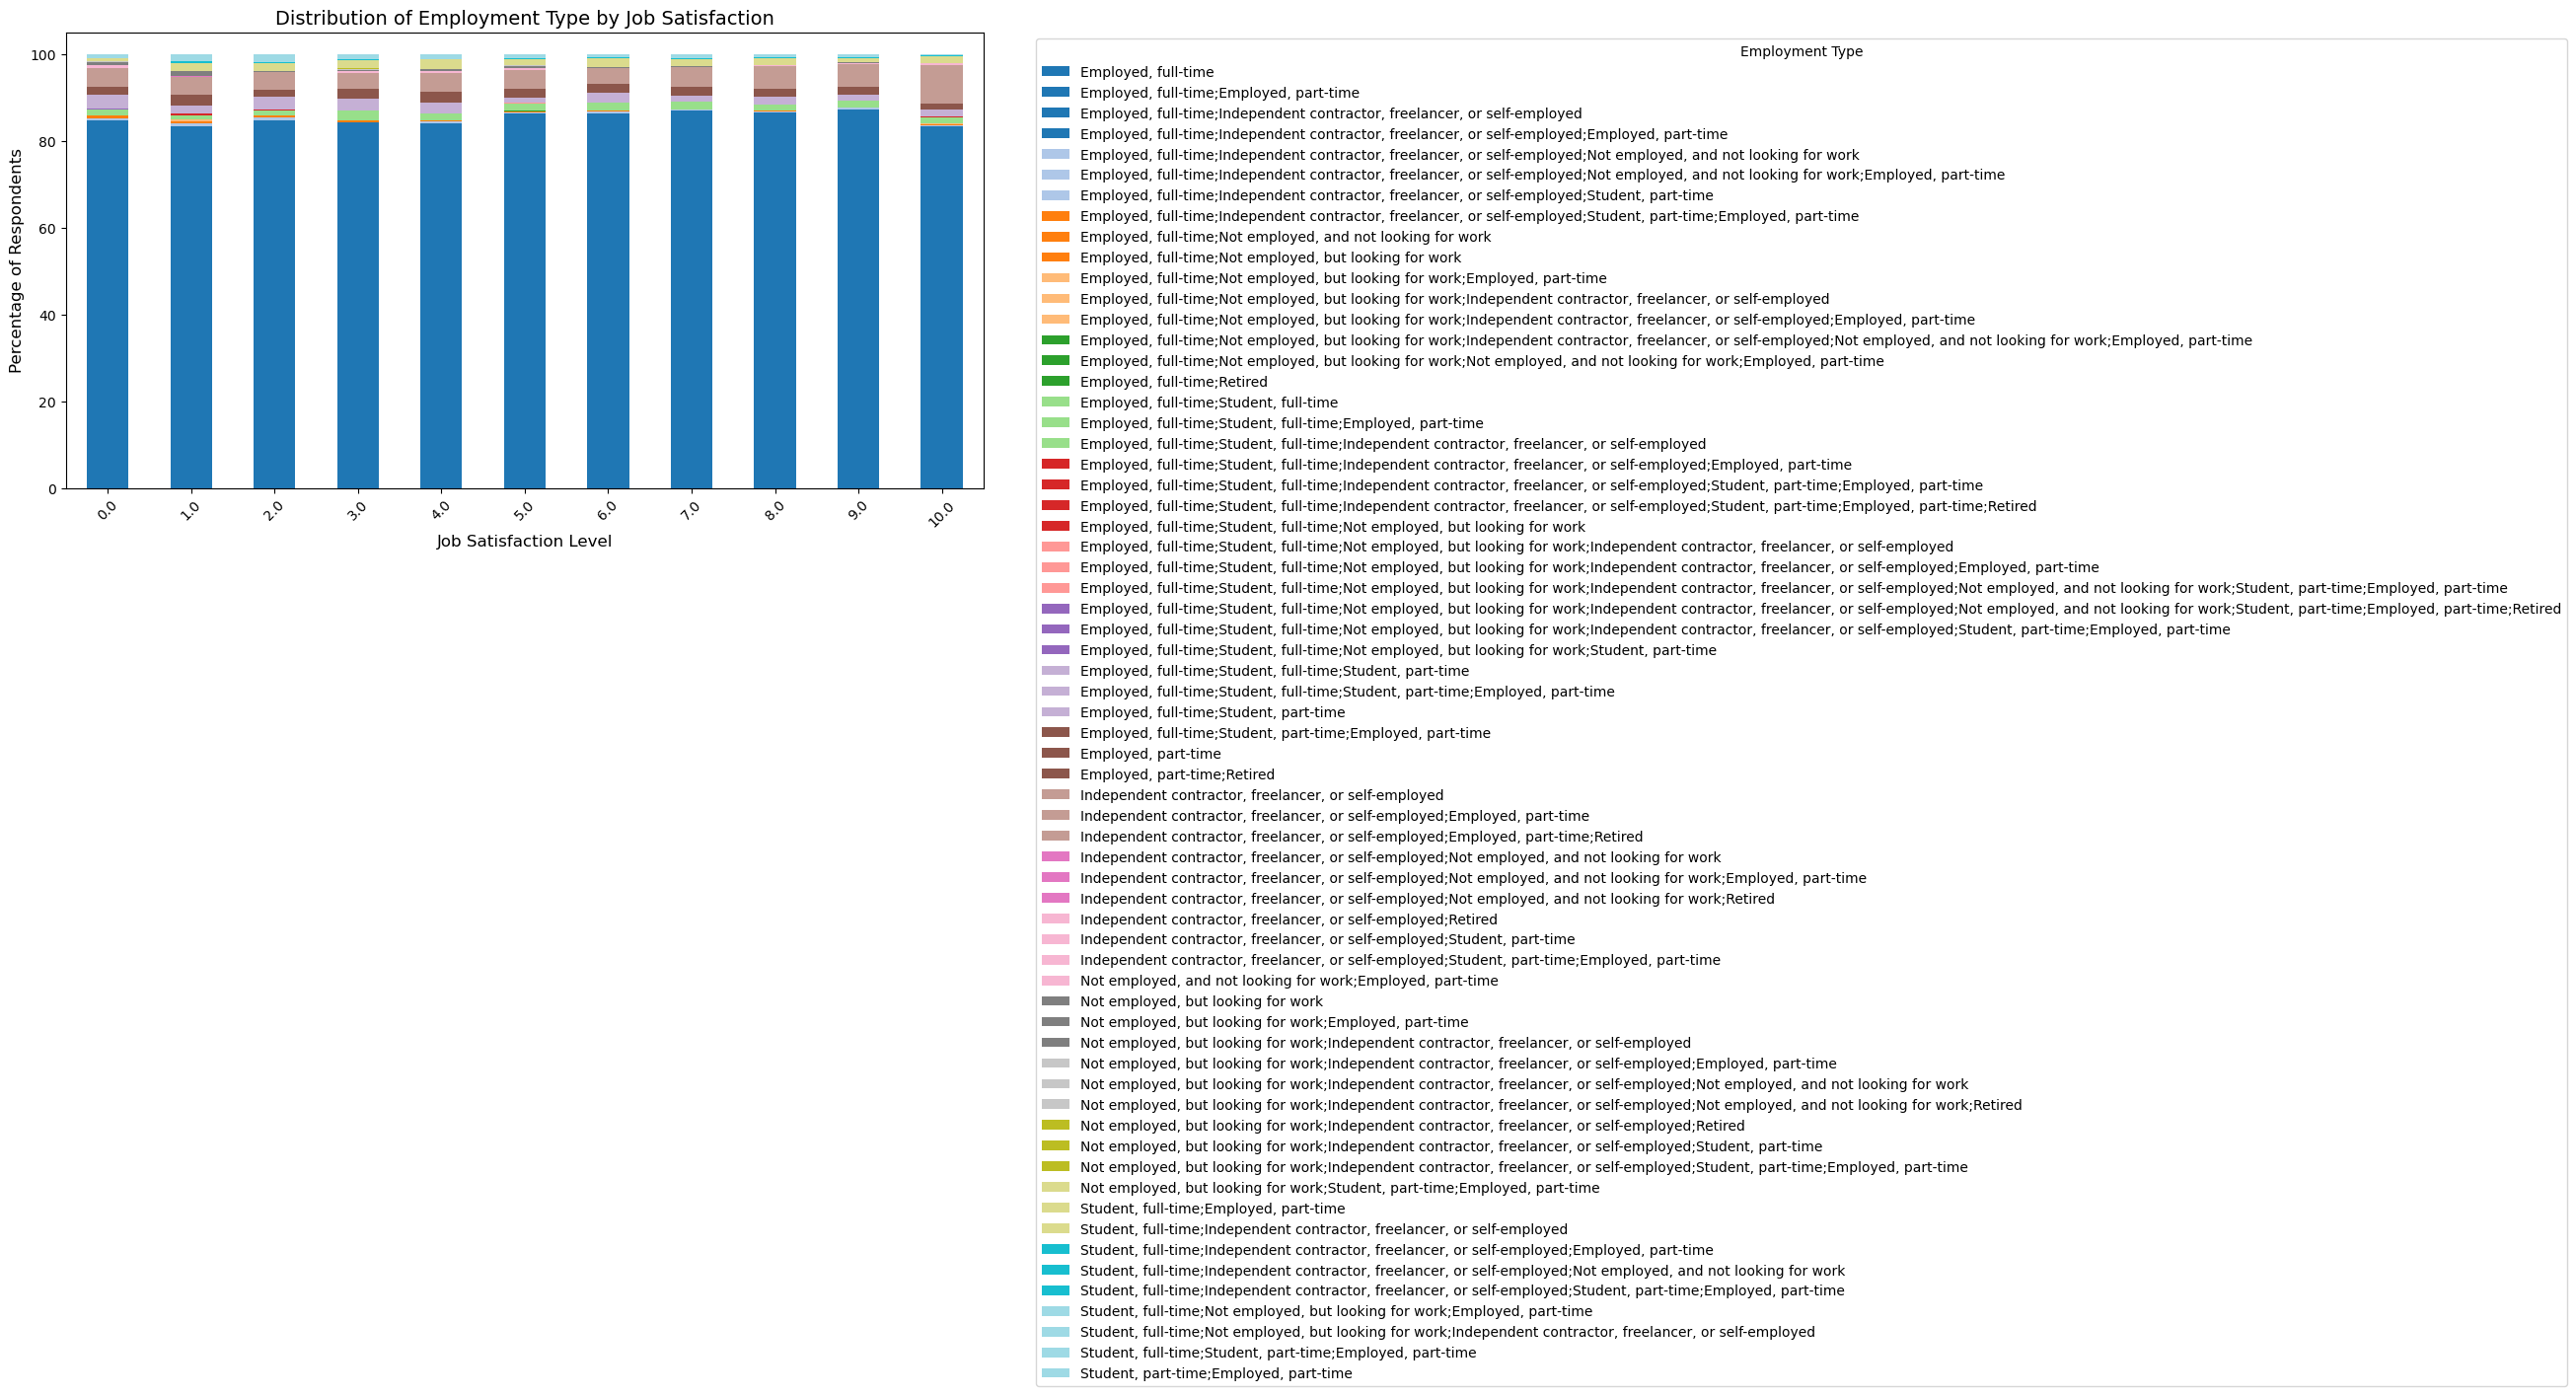

In [88]:
##Write your code here

# Select relevant columns and drop missing values
df_emp = df[['Employment', 'JobSat']].dropna()

# Pivot table: count of Employment types per JobSat level
pivot_table = df_emp.pivot_table(index='JobSat', columns='Employment', aggfunc='size', fill_value=0)

# Convert counts to percentages per JobSat level
pivot_table_percent = pivot_table.div(pivot_table.sum(axis=1), axis=0) * 100

# Plot stacked bar chart
pivot_table_percent.plot(kind='bar', stacked=True, figsize=(12,6), colormap='tab20')

plt.title('Distribution of Employment Type by Job Satisfaction', fontsize=14)
plt.xlabel('Job Satisfaction Level', fontsize=12)
plt.ylabel('Percentage of Respondents', fontsize=12)
plt.legend(title='Employment Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Task 4: Exploring Technology Preferences Using Stacked Charts


##### 1. Stacked Chart for Preferred Programming Languages by Age Group


Analyze how programming language preferences (`LanguageAdmired`) vary across age groups.


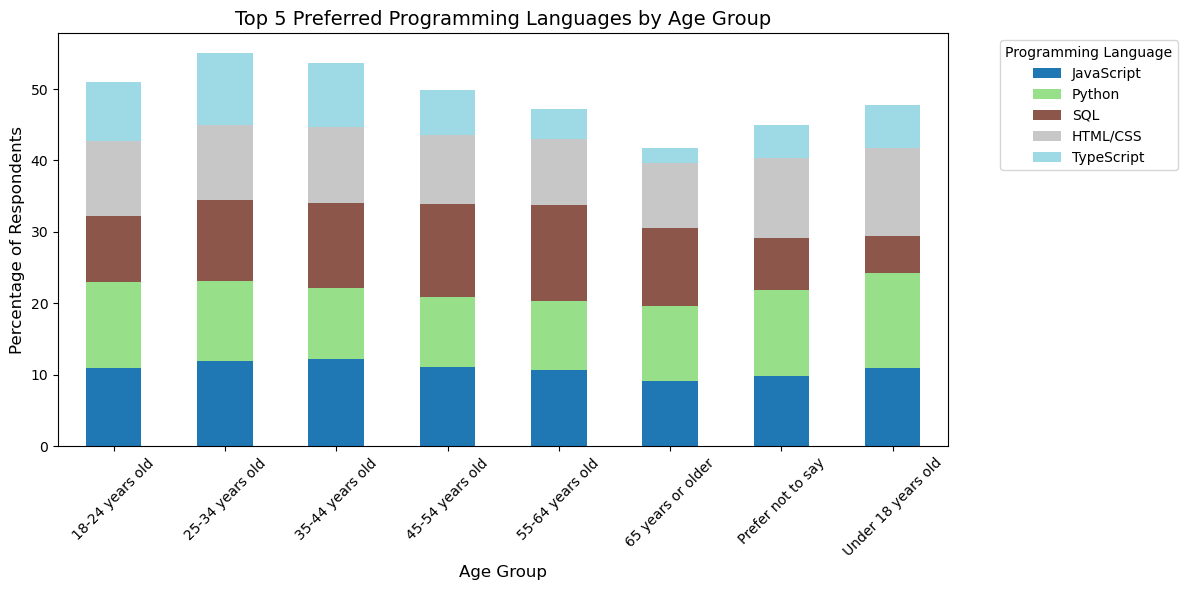

In [90]:
##Write your code here


df_lang = df[['Age', 'LanguageAdmired']].dropna()

# Split multiple languages if separated by semicolons and explode into separate rows
df_lang = df_lang.assign(LanguageAdmired=df_lang['LanguageAdmired'].str.split(';')).explode('LanguageAdmired')

# Strip whitespace
df_lang['LanguageAdmired'] = df_lang['LanguageAdmired'].str.strip()

# Pivot table: count of languages per age group
pivot_table = df_lang.pivot_table(index='Age', columns='LanguageAdmired', aggfunc='size', fill_value=0)

# Convert counts to percentages for proportion in each age group
pivot_table_percent = pivot_table.div(pivot_table.sum(axis=1), axis=0) * 100

# Optional: select top 5 languages overall for clarity
top_langs = pivot_table.sum().sort_values(ascending=False).head(5).index
pivot_table_percent = pivot_table_percent[top_langs]

# Plot stacked bar chart
pivot_table_percent.plot(kind='bar', stacked=True, figsize=(12,6), colormap='tab20')

plt.title('Top 5 Preferred Programming Languages by Age Group', fontsize=14)
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Percentage of Respondents', fontsize=12)
plt.legend(title='Programming Language', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##### 2. Stacked Chart for Technology Adoption by Employment Type


Explore how admired platforms (`PlatformAdmired`) differ across employment types (e.g., full-time, freelance)


C:\Users\praka\AppData\Local\Temp\ipykernel_14228\3199308108.py:33: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


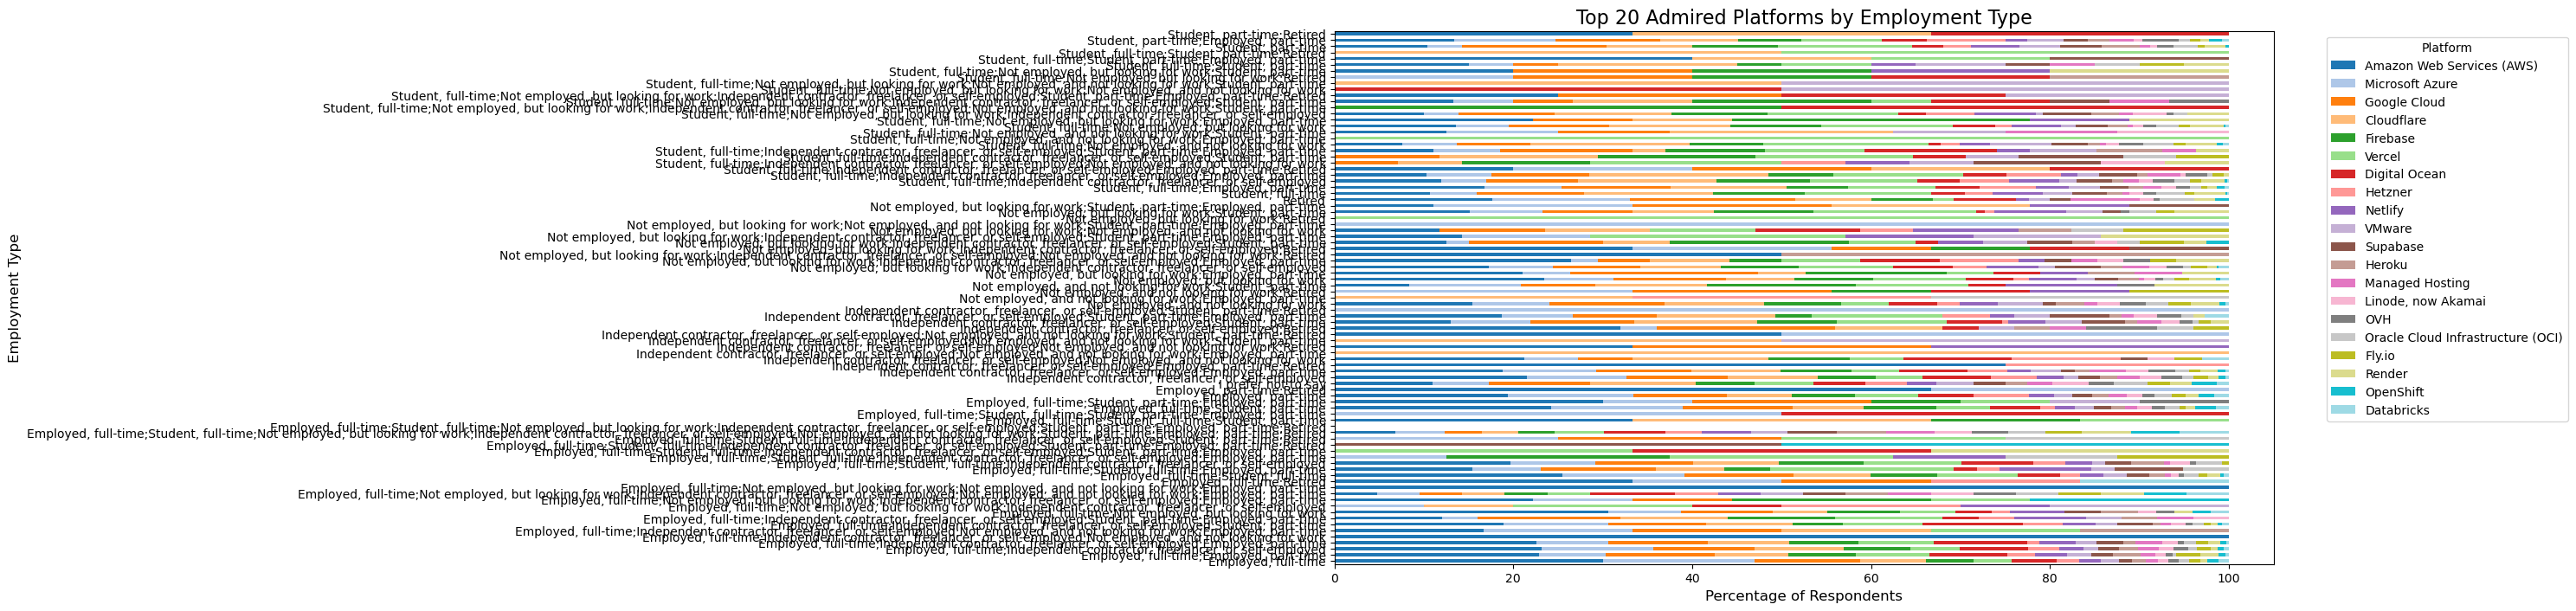

In [96]:
##Write your code here


import pandas as pd
import matplotlib.pyplot as plt

# Select relevant columns and drop missing values
df_platform = df[['Employment', 'PlatformAdmired']].dropna()

# Split multiple platforms if separated by semicolons and explode into separate rows
df_platform = df_platform.assign(PlatformAdmired=df_platform['PlatformAdmired'].str.split(';')).explode('PlatformAdmired')

# Strip whitespace
df_platform['PlatformAdmired'] = df_platform['PlatformAdmired'].str.strip()

# Pivot table: count of platforms per employment type
pivot_table = df_platform.pivot_table(index='Employment', columns='PlatformAdmired', aggfunc='size', fill_value=0)

# Select top 20 platforms overall
top_platforms = pivot_table.sum().sort_values(ascending=False).head(20).index
pivot_table_top = pivot_table[top_platforms]

# Convert counts to percentages per employment type
pivot_table_percent = pivot_table_top.div(pivot_table_top.sum(axis=1), axis=0) * 100

# Plot horizontal stacked bar chart
pivot_table_percent.plot(kind='barh', stacked=True, figsize=(14,8), colormap='tab20')

plt.title('Top 20 Admired Platforms by Employment Type', fontsize=16)
plt.xlabel('Percentage of Respondents', fontsize=12)
plt.ylabel('Employment Type', fontsize=12)
plt.legend(title='Platform', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


### Final Step: Review


In this lab, you focused on using stacked charts to understand the composition and comparison within the dataset. Stacked charts provided insights into job satisfaction, compensation, and preferred databases across age groups and employment types.


## Summary


After completing this lab, you will be able to:

- Use stacked charts to analyze the composition of data across categories, such as job satisfaction and compensation by age group.

- Compare data across different dimensions using stacked charts, enhancing your ability to communicate complex relationships in the data.

- Visualize distributions across multiple categories, such as employment type by satisfaction, to gain a deeper understanding of patterns within the dataset.


## Author:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2024-10-28|1.2|Madhusudhan Moole|Updated lab|
|2024-10-16|1.1|Madhusudhan Moole|Updated lab|
|2024-10-15|1.0|Raghul Ramesh|Created lab|
--!>


Copyright © IBM Corporation. All rights reserved.
